In [143]:
from codecs import ignore_errors

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [144]:
df = pd.read_csv("data/framingham.csv")

In [145]:
# EDA

In [146]:
df.shape

(4240, 16)

In [147]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


In [148]:
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [149]:
df.isna().sum() #there is missing values
# glucose ,totChol , BMI, heartRate = (Median)
# cigsPerDay = (Median or who is not smoking fill with 0 )
# BPMeds = (mod)
# Education = (mod)

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [150]:
df.duplicated().sum() # there is no duplicated

np.int64(0)

In [151]:
df.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4240.000000,4240.000000,4135.000000,4240.000000,4211.000000,4187.000000,4240.000000,4240.000000,4240.000000,4190.000000,4240.000000,4240.000000,4221.000000,4239.000000,3852.000000,4240.000000
mean,0.429245,49.580189,1.979444,0.494104,9.005937,0.029615,0.005896,0.310613,0.025708,236.699523,132.354599,82.897759,25.800801,75.878981,81.963655,0.151887
std,0.495027,8.572942,1.019791,0.500024,11.922462,0.169544,0.076569,0.462799,0.158280,44.591284,22.033300,11.910394,4.079840,12.025348,23.954335,0.358953
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,90.000000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [152]:
#The highest values sysBP = 296 and totChol = 696 look very high, but they are still possible in real patients with severe conditions. There are no impossible values like a blood pressure of 0. So I think these are real high-risk patients, not errors, and I keep them instead of deleting them.

In [153]:
df["TenYearCHD"].value_counts(normalize=True)* 100# Target is TenYearCHD but there is imbalanced data , approxi

TenYearCHD
0    84.811321
1    15.188679
Name: proportion, dtype: float64

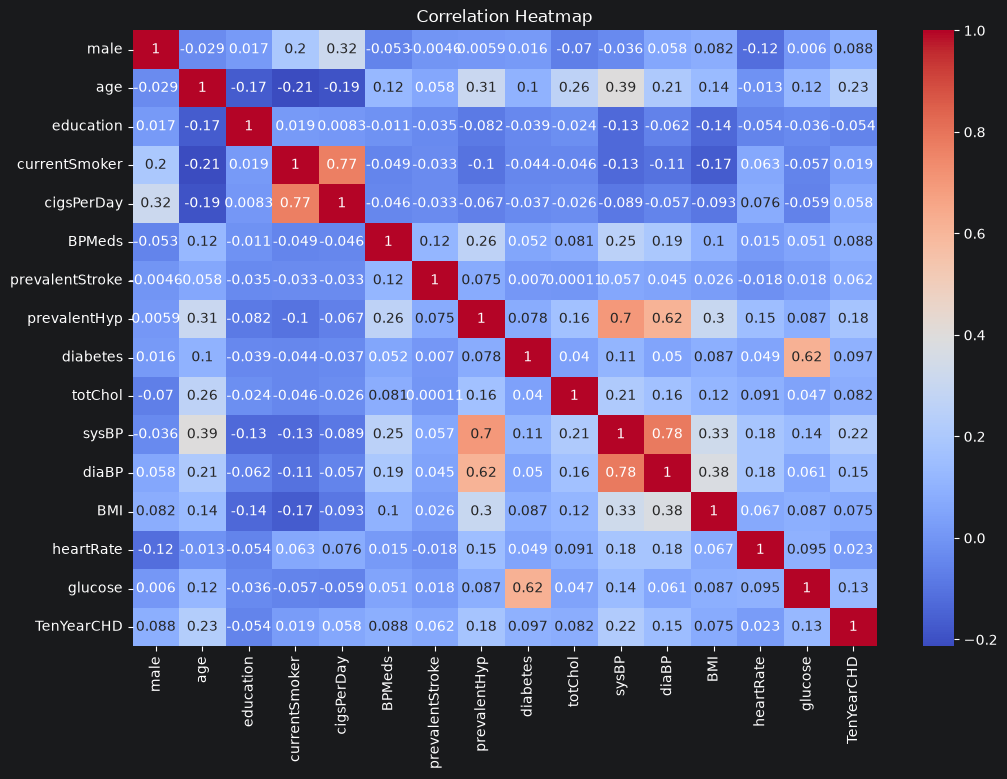

In [154]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [155]:
# No single feature determines the disease on its own; the risk comes from a combination of many factors. That's why I am going to use an ML model that evaluates all features together.

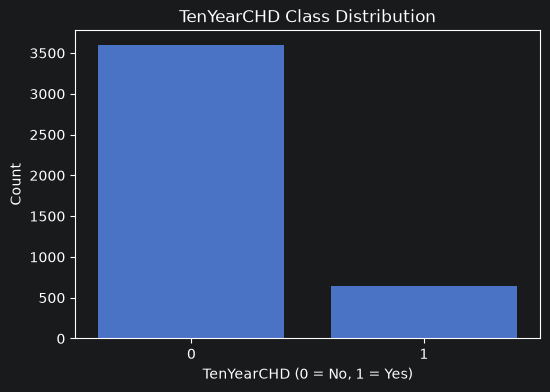

In [156]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="TenYearCHD")
plt.title("TenYearCHD Class Distribution")
plt.xlabel("TenYearCHD (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

In [157]:
#The dataset is imbalanced: about 85% of patients are in class 0 (no CHD) and only ~15% in class 1 (CHD). Because of this, accuracy would be misleading. That's why I will use recall and ROC-AUC as the main metrics and try balancing techniques such as class_weight or SMOTE.

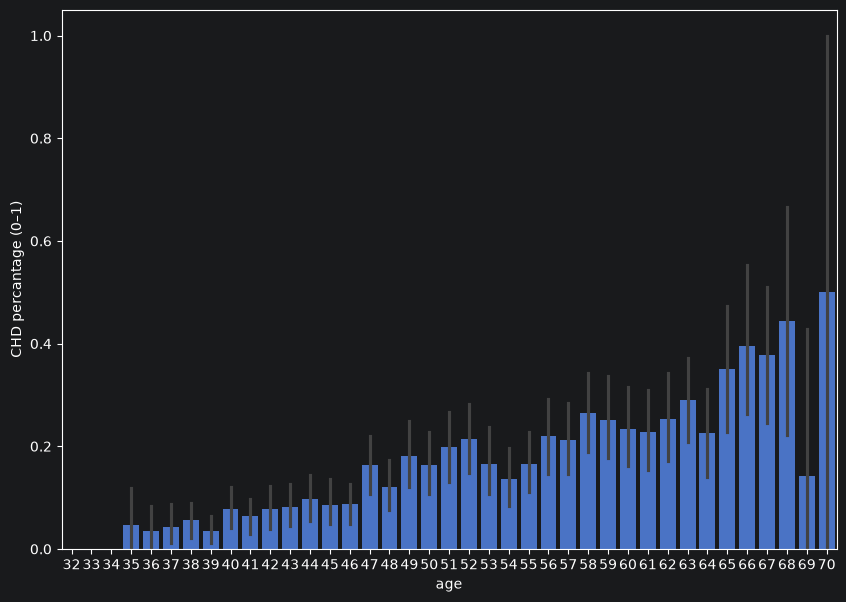

In [158]:
plt.figure(figsize=(10,7))
sns.barplot(data=df, x="age", y="TenYearCHD")
plt.ylabel("CHD percantage (0–1)")
plt.show()

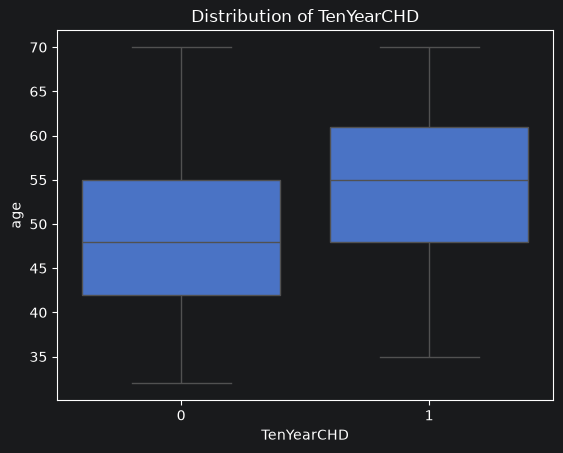

In [159]:
sns.boxplot(data=df, x="TenYearCHD", y="age")
plt.title("Distribution of TenYearCHD")
plt.show()
plt.show()

In [160]:
# Barplot and boxplot , shows high correlletion between CHD and age . When age increases CHD percantage also increasing .The CHD positive group (TenYearCHD = 1) has a higher median age (~55) than the CHD-negative group (~47), indicating that age is an important risk factor.

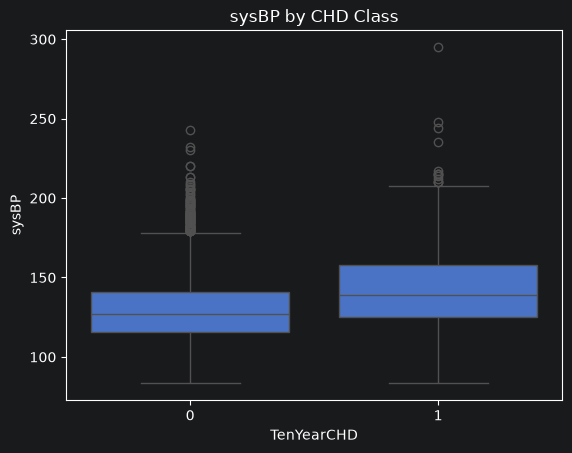

In [161]:
sns.boxplot(data=df, x="TenYearCHD", y="sysBP")
plt.title("sysBP by CHD Class")
plt.show()

In [162]:
# People who got heart disease (class 1) have higher blood pressure than those who didn't (class 0). We can see the box for class 1 is higher. This matches the correlation we saw earlier, so blood pressure looks like an important risk factor. There are also some very high values (outliers), but these are probably real patients with high blood pressure, not mistakes.

In [163]:
# Train Test Split

In [164]:
from sklearn.model_selection import train_test_split

In [165]:
# target
X = df.drop("TenYearCHD", axis=1)
y = df["TenYearCHD"]

In [166]:
# split
X_train , X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [167]:
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (2968, 15)  Test: (1272, 15)


In [168]:
# Missing values

In [169]:
print(X_train.isna().sum()[X_train.isna().sum() > 0])
# glucose ,totChol , BMI, heartRate = (Median)
# cigsPerDay = (Median or who is not smoking fill with 0 )
# BPMeds = (mod)
# Education = (mod)

education      80
cigsPerDay     22
BPMeds         43
totChol        40
BMI            11
heartRate       1
glucose       287
dtype: int64


In [170]:
# train median (Separately for each column)
medians = X_train.median()
print(medians)

male                 0.00
age                 49.00
education            2.00
currentSmoker        1.00
cigsPerDay           1.00
BPMeds               0.00
prevalentStroke      0.00
prevalentHyp         0.00
diabetes             0.00
totChol            234.00
sysBP              128.00
diaBP               82.00
BMI                 25.36
heartRate           75.00
glucose             78.00
dtype: float64


In [171]:
# Filling with using medians for test and train
X_train = X_train.fillna(medians)
X_test = X_test.fillna(medians)

In [172]:
X_train.isna().sum().sum()

np.int64(0)

In [173]:
X_test.isna().sum().sum()

np.int64(0)

In [174]:
# I filled missing values with using fillna(medians).
# I calculated the medians only on the training set, then applied them to the test set.
# Because I want to protect my model from data leakage.

In [175]:
#

In [176]:
# SCALING

In [177]:
X_train.nunique().sort_values()

male                  2
currentSmoker         2
BPMeds                2
prevalentStroke       2
prevalentHyp          2
diabetes              2
education             4
cigsPerDay           31
age                  39
heartRate            70
glucose             128
diaBP               139
sysBP               222
totChol             230
BMI                1183
dtype: int64

In [178]:
X_train.value_counts()

male  age  education  currentSmoker  cigsPerDay  BPMeds  prevalentStroke  prevalentHyp  diabetes  totChol  sysBP  diaBP  BMI    heartRate  glucose
1     54   2.0        1              40.0        0.0     0                0             0         245.0    152.0  82.0   23.71  75.0       75.0       1
      44   3.0        1              30.0        0.0     0                0             0         363.0    140.0  87.0   26.44  95.0       79.0       1
0     46   2.0        1              15.0        0.0     0                0             0         232.0    115.0  70.0   25.18  75.0       59.0       1
1     38   2.0        1              15.0        0.0     0                0             0         150.0    123.0  76.0   20.39  60.0       82.0       1
      40   2.0        1              15.0        0.0     0                0             0         200.0    122.5  75.0   20.25  60.0       67.0       1
                                                                                             

In [179]:
from sklearn.preprocessing import StandardScaler

In [180]:
# StandartScaler it is better than other scalers for LogisticRegression

In [181]:
# Columns which has wide range
# this columns going to scaling.
num_cols = ["age", "cigsPerDay", "totChol", "sysBP", "diaBP", "BMI", "heartRate", "glucose"]

scaler = StandardScaler()

In [182]:
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
# I copied because some columns have 0 and 1 .
# just for protection

In [183]:
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

In [184]:
X_train_scaled.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose
4097,1,0.525340,2.0,1,2.616082,0.0,0,0,0,0.190338,0.888300,-0.082521,-0.513420,-0.084089,-0.300761
3165,1,-0.646204,3.0,1,1.768676,0.0,0,0,0,2.933585,0.345196,0.335721,0.152446,1.581427,-0.117332
2499,0,-0.411896,2.0,1,0.497566,0.0,0,0,0,-0.111884,-0.786270,-1.086303,-0.154877,-0.084089,-1.034480
3345,1,-1.349131,2.0,1,0.497566,0.0,0,0,0,-2.018208,-0.424201,-0.584412,-1.323190,-1.333227,0.020240
3596,1,-1.114822,2.0,1,0.497566,0.0,0,0,0,-0.855816,-0.446830,-0.668060,-1.357337,-1.333227,-0.667621


In [185]:
# num_cols are scaled.

In [186]:
#

In [187]:
# Before model , I want to see which model giving best score for this project.
# That's why I ll use Lazypredict

In [188]:
from lazypredict.Supervised import LazyClassifier

In [189]:
classifier= LazyClassifier(verbose=0, ignore_warnings=True)
models, predictions = classifier.fit(X_train_scaled, X_test_scaled, y_train, y_test)

In [190]:
# ROC AUC
models.sort_values("ROC AUC", ascending=False)

#Logistic Reg
#CalibratedClassifierCV
#LinearSVC

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Time Taken
Model,,,,,,,
LogisticRegression,0.855346,0.549204,0.715425,0.807978,0.831833,0.855346,0.007637
CalibratedClassifierCV,0.847484,0.525662,0.712968,0.792957,0.802626,0.847484,0.028627
LinearSVC,0.850629,0.523320,0.712330,0.792373,0.824286,0.850629,0.007855
RidgeClassifierCV,0.850629,0.523320,0.711359,0.792373,0.824286,0.850629,0.008828
RidgeClassifier,0.850629,0.523320,0.711354,0.792373,0.824286,0.850629,0.009813
LinearDiscriminantAnalysis,0.849057,0.547589,0.711335,0.804844,0.809966,0.849057,0.014231
GaussianNB,0.828616,0.581716,0.708045,0.808309,0.797345,0.828616,0.007907
ExtraTreesClassifier,0.850629,0.523320,0.705288,0.792373,0.824286,0.850629,0.141854
QuadraticDiscriminantAnalysis,0.830189,0.559546,0.703274,0.801725,0.789096,0.830189,0.013230


In [191]:
# Models

In [192]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, balanced_accuracy_score

In [193]:
# I used class_weight="balanced" because the data is imbalanced 85% healthy, 15% at risk, so it makes the model pay more attention to the rare at-risk class and catch those patients better.

In [194]:
log_reg    = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
lin_svc    = LinearSVC(class_weight="balanced", random_state=42)
calibrated = CalibratedClassifierCV(LinearSVC(class_weight="balanced", random_state=42))
# I set max_iter as a 1000 for avoid the ConvergenceWarning.

In [195]:
# Train
log_reg.fit(X_train_scaled, y_train)
lin_svc.fit(X_train_scaled, y_train)
calibrated.fit(X_train_scaled, y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",LinearSVC(cla...ndom_state=42)
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary <n_jobs>` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
Name,Type,Value
"calibrated_classifiers_ calibrated_classifiers_: list (len() equal to cv or 1 if `ensemble=False`)The list of classifier and calibrator pairs.- When `ensemble=True`, `n_cv` fitted `estimator` and calibrator pairs. `n_cv` is the number of cross-validation folds.- When `ensemble=False`, the `estimator`, fitted on all the data, and fitted calibrator... versionchanged:: 0.24 Single calibrated classifier case when `ensemble=False`.",list,"[<sklearn.cali...t 0x110e23e90>, 

In [196]:
print("LogReg     :", roc_auc_score(y_test, log_reg.predict_proba(X_test_scaled)[:, 1]))
#I use [:, 1] to take only the probability of being at risk (class 1), because ROC-AUC needs that single column.

LogReg     : 0.7155250815417946


In [197]:
print("LinearSVC  :", roc_auc_score(y_test, lin_svc.decision_function(X_test_scaled)))
# LinearSVC does not produce probabilities, that's why I used decision function

LinearSVC  : 0.7151965335809347


In [198]:
print("Calibrated :", roc_auc_score(y_test, calibrated.predict_proba(X_test_scaled)[:, 1]))

Calibrated : 0.7155155584124944


In [199]:
# Hyperparameter

In [200]:
# 1) Logistic Regression hyperparamater

In [201]:
from sklearn.model_selection import GridSearchCV

In [202]:
param_grid1 = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "class_weight": [None, "balanced"],
    "penalty": ["elasticnet"],
    "solver": ["saga"],
    "l1_ratio": [0.0,0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    "max_iter": [3000],
}

In [203]:
grid_lr = GridSearchCV(
    LogisticRegression(class_weight="balanced", random_state=42),
    param_grid = param_grid1,
    n_jobs=-1,
    scoring="f1",
    cv=5,
)

In [204]:
grid_lr.fit(X_train_scaled, y_train)

/Users/emrekaya/PycharmProjects/heart_risk_predictor/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/emrekaya/PycharmProjects/heart_risk_predictor/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of p

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'class_weight': [None, 'balanced'], 'l1_ratio': [0.0, 0.1, ...], 'max_iter': [3000], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbos

In [205]:
print("Best parameters:", grid_lr.best_params_)

Best parameters: {'C': 0.1, 'class_weight': 'balanced', 'l1_ratio': 0.2, 'max_iter': 3000, 'penalty': 'elasticnet', 'solver': 'saga'}


In [206]:
best_model_logistic = grid_lr.best_estimator_

In [207]:
y_pred  = best_model_logistic.predict(X_test_scaled)

In [208]:
y_proba = best_model_logistic.predict_proba(X_test_scaled)[:, 1]

In [209]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score,f1_score

In [210]:
print("Test ROC-AUC:", roc_auc_score(y_test, y_proba))

Test ROC-AUC: 0.7148965550079757


In [211]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Confusion Matrix:
 [[713 364]
 [ 73 122]]


In [212]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.66      0.77      1077
           1       0.25      0.63      0.36       195

    accuracy                           0.66      1272
   macro avg       0.58      0.64      0.56      1272
weighted avg       0.81      0.66      0.70      1272



In [213]:
# after hyperparameter tuning (Logistic Reg);
# Model catches 63% of at risk patients.
# Accuracy dropped 85% to 66% because I used class_weight = balanced.
# I used class_weight = balanced because model focus on finding sick patients instead of just being correct overall
#This is a good trade off for health screening, because missing a sick patient is worse than a false alarm.

In [214]:
##

In [215]:
# 2) LinearSVC hyperparamater

In [216]:
param_grid2 = {
    "C": [0.01, 0.1, 1, 10],
    "loss": ["squared_hinge"],
    "dual": [False],
    "class_weight": [None, "balanced"],
}

In [217]:
grid_svc = GridSearchCV(
    LinearSVC(max_iter=5000, random_state=42),
    param_grid2,
    cv=5,
    scoring="f1"
)

In [218]:
grid_svc.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LinearSVC(max...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'class_weight': [None, 'balanced'], 'dual': [False], 'loss': ['squared_hinge']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, de

In [219]:
print("LinearSVC :", grid_svc.best_params_)

LinearSVC : {'C': 0.1, 'class_weight': 'balanced', 'dual': False, 'loss': 'squared_hinge'}


In [220]:
svc_best = grid_svc.best_estimator_

In [221]:
y_pred_svc  = svc_best.predict(X_test_scaled)
y_score_svc = svc_best.decision_function(X_test_scaled)

In [222]:
print("Test ROC-AUC:", (roc_auc_score(y_test, y_score_svc)))
print("Classification Report:\n", classification_report(y_test, y_pred_svc))

Test ROC-AUC: 0.7150536866414304
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.66      0.77      1077
           1       0.25      0.63      0.36       195

    accuracy                           0.66      1272
   macro avg       0.58      0.64      0.56      1272
weighted avg       0.81      0.66      0.70      1272



In [223]:
# Same results as a LogisticRegression . It makes sense because both of them linear models . That's why I m going to use tree based model.

In [224]:
#

In [225]:
# Linear models results are same , I think this is because both of them try to separate the data with a straight line. Random Forest was not very good in LazyPredict, but maybe with hyperparameter tuning it can do better, so I wanted to try it and see if a non linear model can improve the results.

In [226]:
# 3) Random Forest hyperparameter

In [227]:
from sklearn.ensemble import RandomForestClassifier

In [228]:
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_leaf": [1, 5, 10],
    "class_weight": ["balanced"],
}

In [229]:
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring="f1"
)

In [230]:
grid_rf.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': ['balanced'], 'max_depth': [None, 5, ...], 'min_samples_leaf': [1, 5, ...], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose

In [231]:
print("RandomForest:", grid_rf.best_params_)

RandomForest: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 5, 'n_estimators': 100}


In [232]:
rf_best = grid_rf.best_estimator_

In [233]:
y_pred_rf  = rf_best.predict(X_test_scaled)

In [234]:
y_proba_rf = rf_best.predict_proba(X_test_scaled)[:, 1]

In [235]:
print("Test ROC-AUC:", round(roc_auc_score(y_test, y_proba_rf), 3))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

Test ROC-AUC: 0.691
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.77      0.83      1077
           1       0.27      0.47      0.34       195

    accuracy                           0.72      1272
   macro avg       0.58      0.62      0.58      1272
weighted avg       0.79      0.72      0.75      1272



In [236]:
#Random Forest got a higher accuracy 0.72 but a lower recall 0.47 and lower ROC-AUC 0.69.

In [237]:
# Supervised Learning Model Comparison
# Summary
# I compared three models after hyperparameter tuning and Both linear models gave the same results. Random Forest had a higher accuracy but a lower recall, which is bad for us because we don't want to miss at-risk patients.
#So Logistic Regression gave the best result. It has the highest recall and it is also easy to understand, so I chose it as my final model.
# Logistic reg Results :
# ROC-AUC = 0.71, Recall (class 1 / at risk)=0.63, Precision (class 1)=0.25, F1 (class 1)=0.36, Accuracy=0.66

In [238]:
# Unsupervised Learning
# for unsupervised learning , I ll use Kmeans

In [250]:
from sklearn.cluster import KMeans
from sklearn.model_selection import cross_val_score

In [251]:
# first I am going to find best k value

In [257]:
inertia = []

In [258]:
for k in range(1, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_train_scaled)
    inertia.append(km.inertia_)

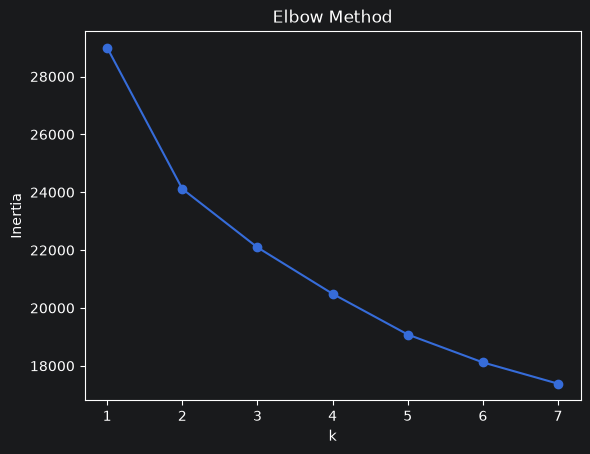

In [259]:
plt.plot(range(1, 8), inertia, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [ ]:
#Here we can see , k = 2

In [260]:
km = KMeans(n_clusters=2, random_state=42, n_init=10)

In [261]:
clusters = km.fit_predict(X_train_scaled)

In [263]:
df_clusters = pd.DataFrame({"cluster": clusters, "risk": y_train.values})

In [264]:
print(df_clusters.groupby("cluster")["risk"].mean())
print(df_clusters.groupby("cluster")["risk"].count())

cluster
0    0.097630
1    0.230769
Name: risk, dtype: float64
cluster
0    1772
1    1196
Name: risk, dtype: int64


In [269]:
# Summary Unsupervised Learning(Kmeans):
#I checked the real risk rate in each group:
# Cluster 0: 9.8% at risk (1772 patients), low risk group
# Cluster 1: 23.1% at risk (1196 patients), high risk group
# K-Means separated patients into a low risk and a high risk group and this shows there is real structure in the data and clusters match the actual heart disease risk.

In [266]:
# I am going to use PCA for 2D because there is 15 features.
from sklearn.decomposition import PCA

In [267]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

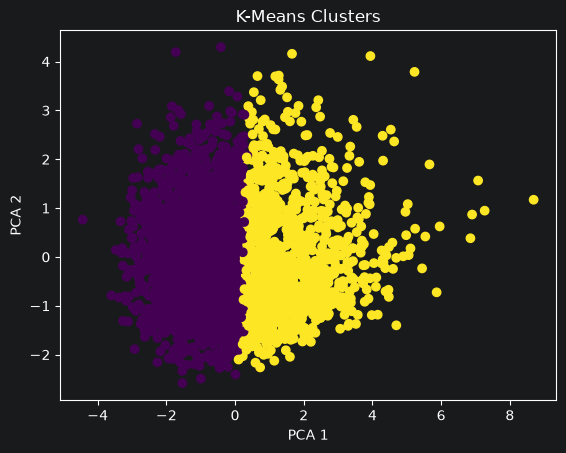

In [268]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means Clusters")
plt.show()

In [ ]:
# Feature Importance

In [273]:
coefs = pd.Series(best_model_logistic.coef_[0], index=X_train_scaled.columns).sort_values()

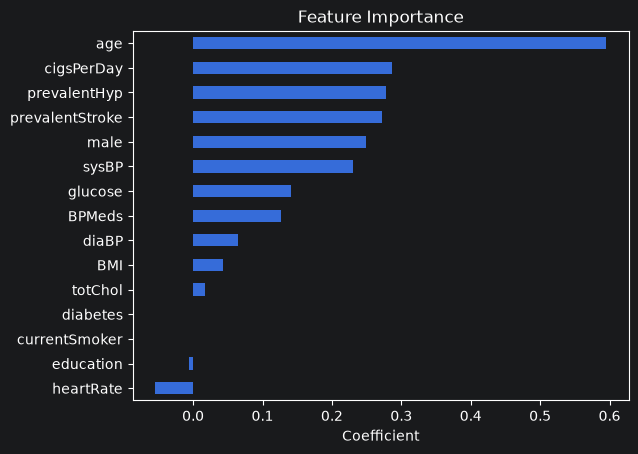

In [277]:
coefs.plot(kind="barh")
plt.title("Feature Importance")
plt.xlabel("Coefficient")
plt.show()

In [ ]:
# The most important risk factors are age,cigsPerday, prevalentHyp(Hypertension) and prevelantStroke and which shows the model learned meaningful patterns not random noises.

# Diabetes and currentSmoker got coefficients near zero because the  elasticnet (L1) penalty removed them as their information was already  in other features.

# As a recommendation; a hospital could prioritize screening for older patients, smokers, and patients with high blood pressure since these factors increase heart disease risk the most.